<a href="https://colab.research.google.com/github/zen-code11/F1-2023-race-results-analysis/blob/main/f1_2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/zen-code11/F1-2023-race-results-analysis/refs/heads/main/Formula1_2023season_raceResults.csv")

In [3]:
df

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
0,Bahrain,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,57,1:33:56.736,25,No,1:36.236
1,Bahrain,2,11,Sergio Perez,Red Bull Racing Honda RBPT,2,57,+11.987,18,No,1:36.344
2,Bahrain,3,14,Fernando Alonso,Aston Martin Aramco Mercedes,5,57,+38.637,15,No,1:36.156
3,Bahrain,4,55,Carlos Sainz,Ferrari,4,57,+48.052,12,No,1:37.130
4,Bahrain,5,44,Lewis Hamilton,Mercedes,7,57,+50.977,10,No,1:36.546
...,...,...,...,...,...,...,...,...,...,...,...
435,Abu Dhabi,16,2,Logan Sargeant,Williams Mercedes,20,58,+87.791,0,No,1:28.580
436,Abu Dhabi,17,24,Guanyu Zhou,Alfa Romeo Ferrari,19,58,+89.422,0,No,1:28.746
437,Abu Dhabi,18,55,Carlos Sainz,Ferrari,16,57,DNF,0,No,1:29.452
438,Abu Dhabi,19,77,Valtteri Bottas,Alfa Romeo Ferrari,18,57,+1 lap,0,No,1:29.863


In [4]:
df[df["Track"].str.contains("Monaco")] # displays all stats from monaco race, similarly we can do that for other race tracks as well

,Track,Position,No,Driver,Team,Starting Grid,Laps,Time/Retired,Points,Set Fastest Lap,Fastest Lap Time
100,Monaco,1,1,Max Verstappen,Red Bull Racing Honda RBPT,1,78,1:48:51.980,25,No,1:16.604
101,Monaco,2,14,Fernando Alonso,Aston Martin Aramco Mercedes,2,78,+27.921,18,No,1:16.674
102,Monaco,3,31,Esteban Ocon,Alpine Renault,3,78,+36.990,15,No,1:16.528
103,Monaco,4,44,Lewis Hamilton,Mercedes,5,78,+39.062,13,Yes,1:15.650
104,Monaco,5,63,George Russell,Mercedes,8,78,+56.284,10,No,1:16.798
105,Monaco,6,16,Charles Leclerc,Ferrari,6,78,+61.890,8,No,1:15.773
106,Monaco,7,10,Pierre Gasly,Alpine Renault,7,78,+62.362,6,No,1:15.831
107,Monaco,8,55,Carlos Sainz,Ferrari,4,78,+63.391,4,No,1:16.449
108,Monaco,9,4,Lando Norris,McLaren Mercedes,10,77,+1 lap,2,No,1:17.844
109,Monaco,10,81,Oscar Piastri,McLaren Mercedes,11,77,+1 lap,1,No,1:17.513


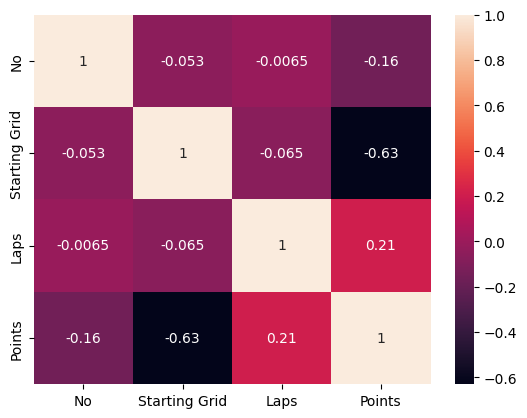

In [5]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True) #using numeric attributes to find a correlation between them

plt.show()

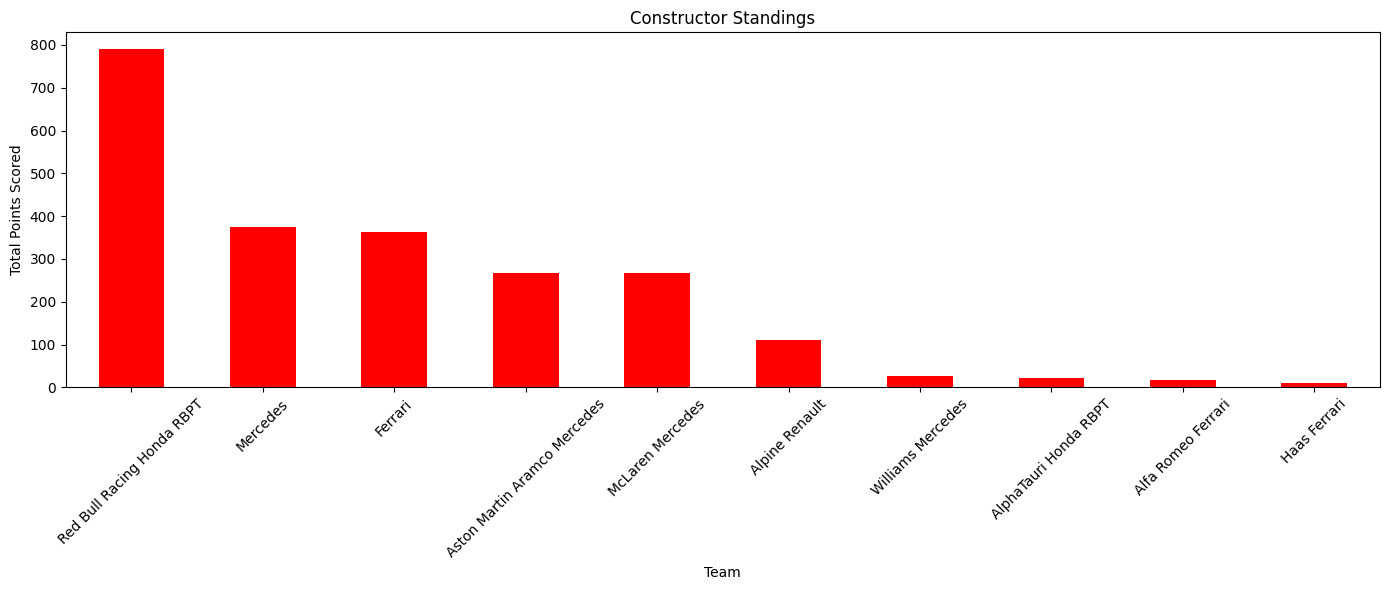

In [21]:
group = df.groupby("Team")      #Constructor Standings
df1 = group["Points"].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
df1.plot(kind="bar",color='red')
plt.ylabel("Total Points Scored")
plt.title("Constructor Standings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

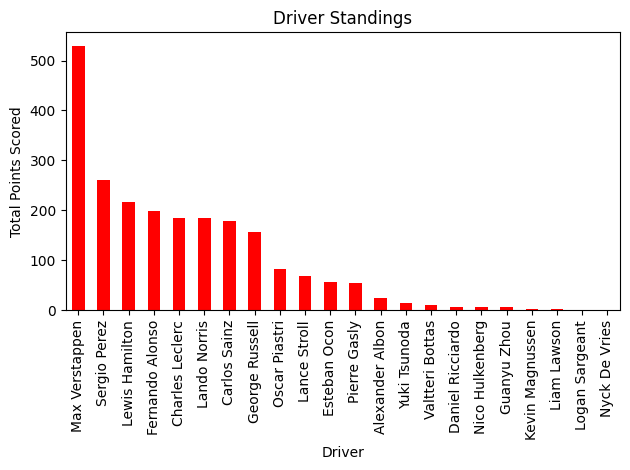

In [10]:
group2 = df.groupby("Driver")    #Driver Standings
df2 = group2["Points"].sum().sort_values(ascending=False)
df2.plot(kind="bar",color='red')
plt.ylabel("Total Points Scored")
plt.title("Driver Standings")
plt.tight_layout()
plt.show()

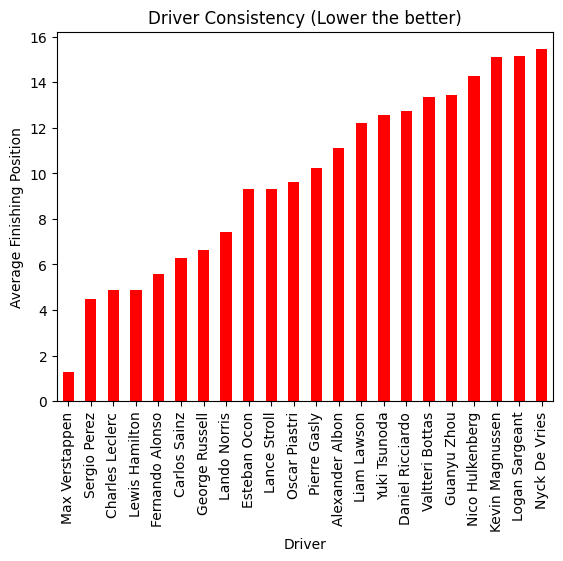

In [19]:
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
df3 = group2["Position"].mean().sort_values()
df3.plot(kind = "bar",color='red')
plt.ylabel("Average Finishing Position")
plt.title("Driver Consistency (Lower the better)")
plt.show()

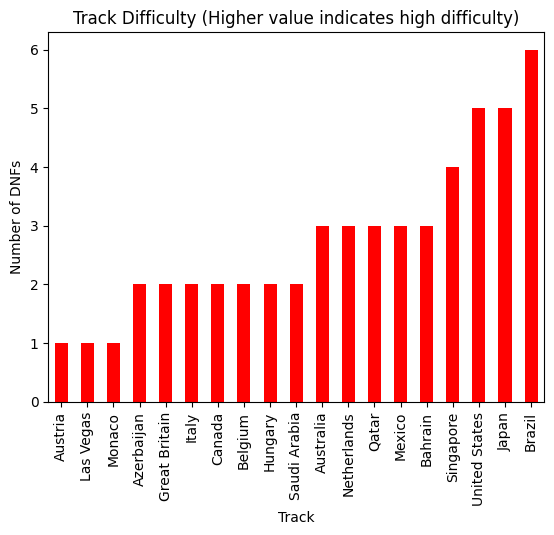

In [22]:
group3 = df.groupby("Track")
dnf_count = df[pd.to_numeric(df["Position"], errors="coerce").isna()].groupby("Track").size().sort_values()
dnf_count.plot(kind = "bar",color='red')
plt.ylabel("Number of DNFs")
plt.title("Track Difficulty (Higher value indicates high difficulty)")
plt.show()

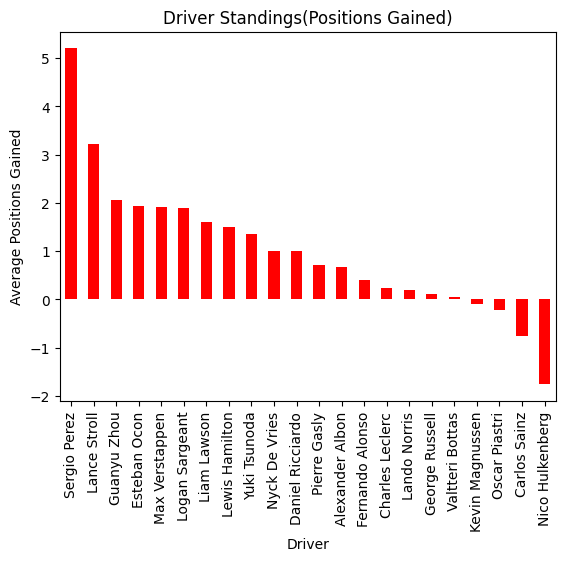

In [23]:
df["Positions Gained"] = pd.to_numeric(df["Starting Grid"] - df["Position"], errors="coerce")
df5 = group2["Positions Gained"].mean().sort_values(ascending=False)
df5.plot(kind = "bar",color='red')
plt.ylabel("Average Positions Gained")
plt.title("Driver Standings(Positions Gained)")
plt.show()